## Imports

In [18]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

## EDA

In [19]:
df = pd.read_csv('datasetml_2026.csv')
df.head()

,cgpa,backlogs,college_tier,country,university_ranking_band,internship_count,aptitude_score,communication_score,specialization,industry,internship_quality_score,placement_status
0,7.397371,1,Tier 2,Canada,100-300,2,53.574150,64.177062,Data Science,Consulting,5.481450,Placed
1,6.889389,0,Tier 3,UK,300+,1,60.687750,88.346052,Data Science,Consulting,4.625099,Placed
2,7.518151,0,Tier 1,UK,100-300,2,64.568750,69.493171,Cybersecurity,Healthcare,5.227939,Placed
3,8.218424,0,Tier 2,UK,100-300,3,73.461500,78.204854,AI/ML,Tech,5.150674,Placed
4,6.812677,1,Tier 2,USA,100-300,4,86.518121,44.680881,Data Science,Consulting,3.888824,Placed


In [20]:
df.shape

(10000, 12)

In [21]:
df.dtypes

cgpa                        float64
backlogs                      int64
college_tier                 object
country                      object
university_ranking_band      object
internship_count              int64
aptitude_score              float64
communication_score         float64
specialization               object
industry                     object
internship_quality_score    float64
placement_status             object
dtype: object

In [22]:
df.describe()

,cgpa,backlogs,internship_count,aptitude_score,communication_score,internship_quality_score
count,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,6.998290,1.248100,1.49930,69.877531,65.158600,5.021436
std,0.802606,1.149904,1.20289,14.700532,14.740446,1.505975
min,4.000000,0.000000,0.00000,30.000000,30.000000,1.000000
25%,6.461928,0.000000,1.00000,59.880399,55.112244,4.012656
50%,6.997924,1.000000,1.00000,70.097368,65.006484,5.017335
75%,7.536865,2.000000,2.00000,80.213934,75.277248,6.031400
max,10.000000,6.000000,5.00000,100.000000,100.000000,10.000000


In [23]:
# cari yg null
df.isnull().sum()

cgpa                        0
backlogs                    0
college_tier                0
country                     0
university_ranking_band     0
internship_count            0
aptitude_score              0
communication_score         0
specialization              0
industry                    0
internship_quality_score    0
placement_status            0
dtype: int64

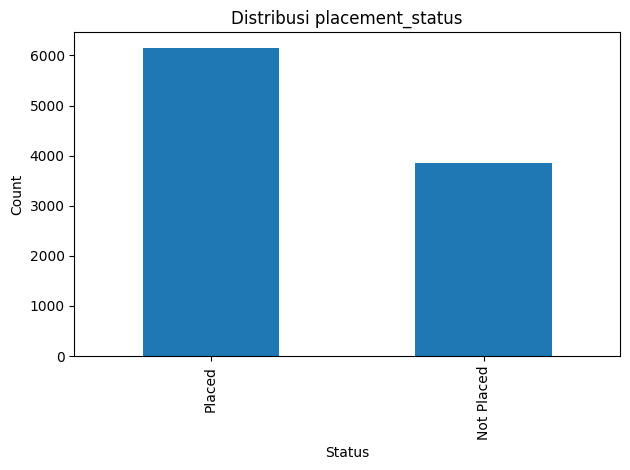

In [24]:
# Distribusi target
df['placement_status'].value_counts().plot(kind='bar')
plt.title('Distribusi placement_status')
plt.xlabel('Status')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

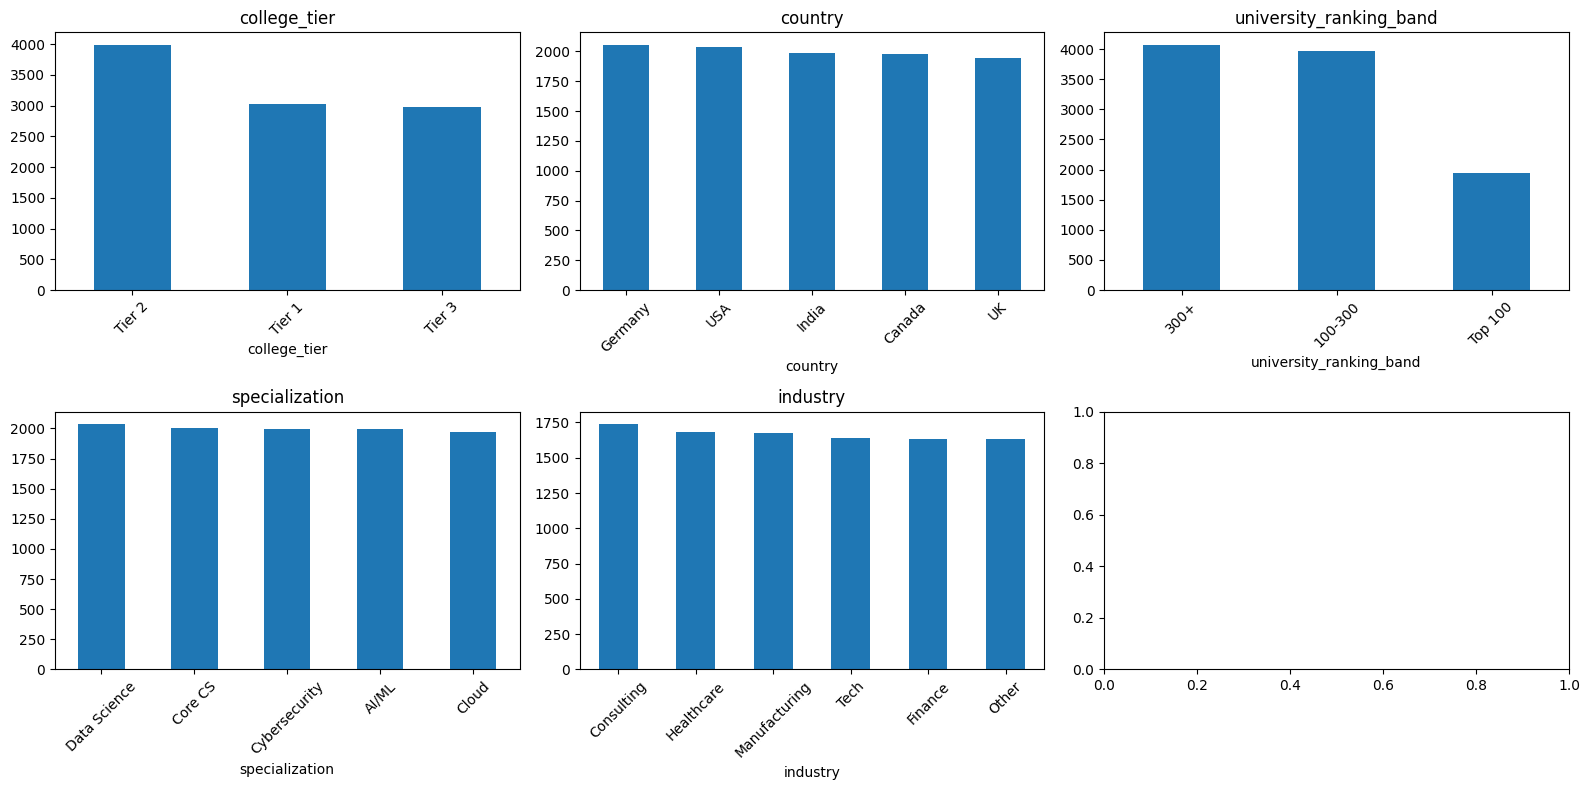

In [25]:
# Distribusi fitur kategorikal
cat_cols = ['college_tier', 'country', 'university_ranking_band', 'specialization', 'industry']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flatten(), cat_cols):
    df[col].value_counts().plot(kind='bar', ax=ax)
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

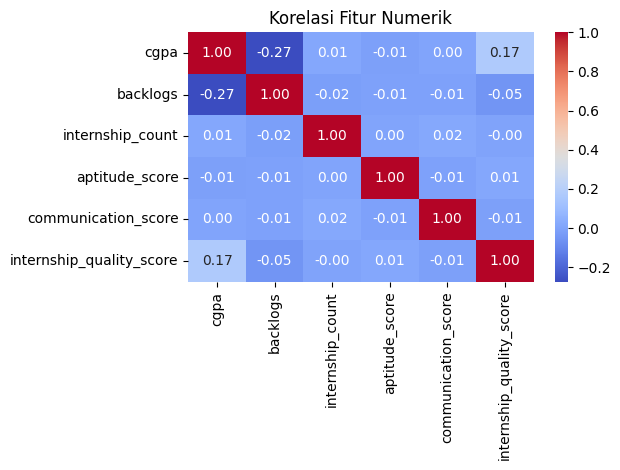

In [26]:
# Korelasi fitur numerik
num_cols = ['cgpa', 'backlogs', 'internship_count', 'aptitude_score',
            'communication_score', 'internship_quality_score']

import seaborn as sns
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Korelasi Fitur Numerik')
plt.tight_layout()
plt.show()

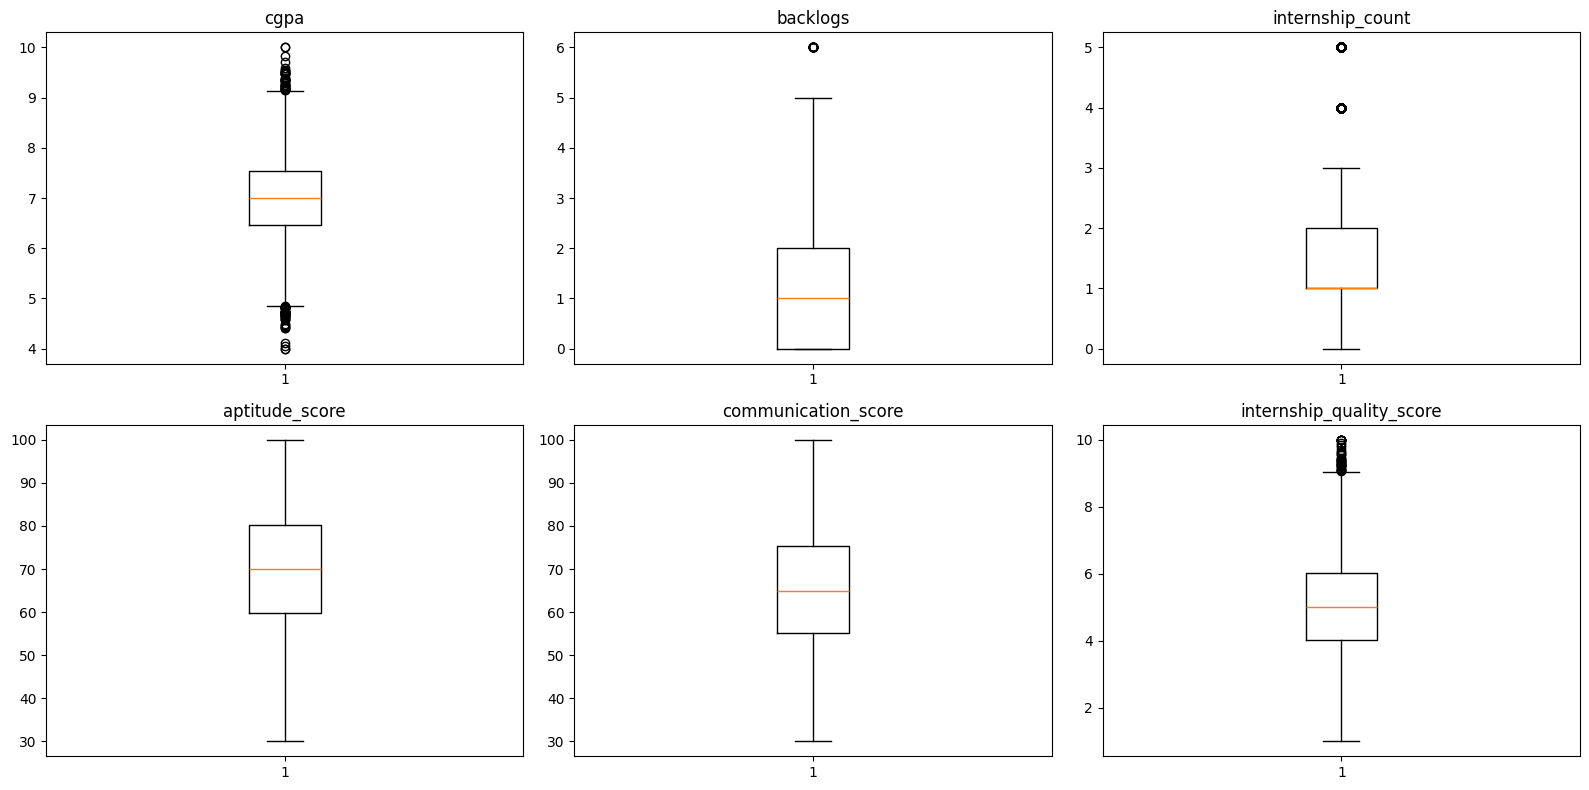

In [27]:
# Outlier
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flatten(), num_cols):
    ax.boxplot(df[col].dropna())
    ax.set_title(col)
plt.tight_layout()
plt.show()

## Preprocessing

In [28]:
# encode kolom kategorikal
cat_cols = ['college_tier', 'country', 'university_ranking_band',
            'specialization', 'industry']
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

In [29]:
# pisah fitur dan target
X = df.drop(columns=['placement_status']).values
y = le.fit_transform(df['placement_status'].astype(str)).reshape(-1, 1)

In [30]:
# normalisasi fitur numerik
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [31]:
# split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val   = train_test_split(X_train, y_train, test_size=0.1, random_state=42)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Train: (7200, 11), Val: (800, 11), Test: (2000, 11)


## Model Testing

Random init, 100 epoch dengan 0.1% learning rate

Training Custom FFNN Model...
Epoch   1/100 [>....................] - loss: 0.6911 - acc: 0.6147 - val_loss: 0.6898 - val_acc: 0.6125
Epoch   2/100 [>....................] - loss: 0.6885 - acc: 0.6147 - val_loss: 0.6874 - val_acc: 0.6125
Epoch   3/100 [>....................] - loss: 0.6862 - acc: 0.6147 - val_loss: 0.6853 - val_acc: 0.6125
Epoch   4/100 [>....................] - loss: 0.6842 - acc: 0.6147 - val_loss: 0.6834 - val_acc: 0.6125
Epoch   5/100 [=>...................] - loss: 0.6823 - acc: 0.6147 - val_loss: 0.6817 - val_acc: 0.6125
Epoch   6/100 [=>...................] - loss: 0.6807 - acc: 0.6147 - val_loss: 0.6802 - val_acc: 0.6125
Epoch   7/100 [=>...................] - loss: 0.6792 - acc: 0.6147 - val_loss: 0.6788 - val_acc: 0.6125
Epoch   8/100 [=>...................] - loss: 0.6779 - acc: 0.6147 - val_loss: 0.6776 - val_acc: 0.6125
Epoch   9/100 [=>...................] - loss: 0.6767 - acc: 0.6147 - val_loss: 0.6766 - val_acc: 0.6125
Epoch  10/100 [==>................

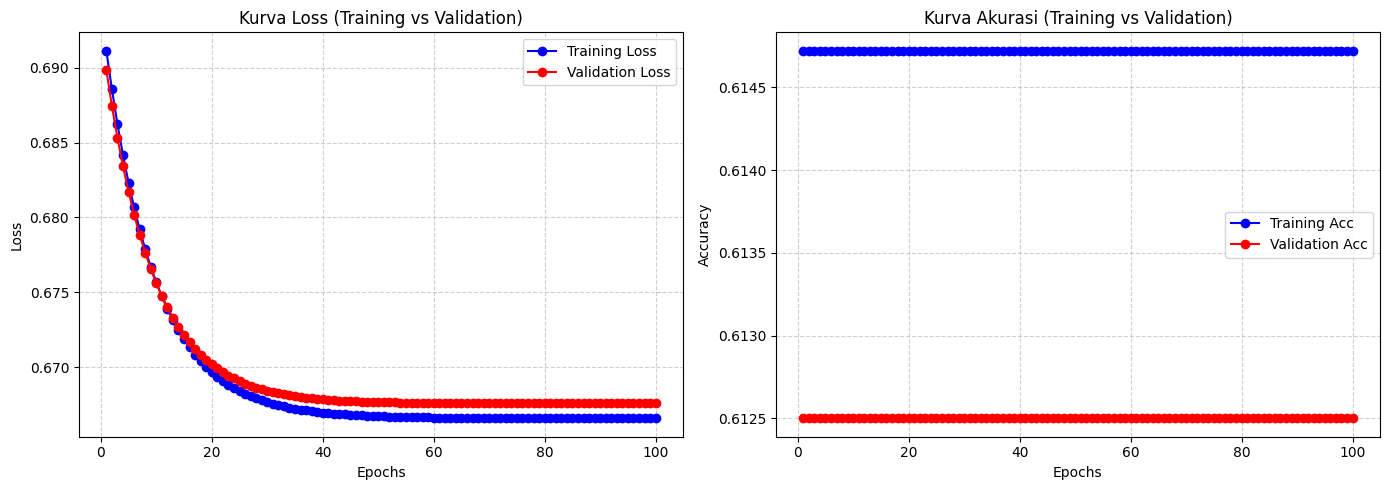


CUSTOM FFNN MODEL - CLASSIFICATION REPORT
--- Laporan Klasifikasi ---
Total Data : 2000
Akurasi    : 61.25%

CONFUSION MATRIX - CUSTOM FFNN
[[   0  775]
 [   0 1225]]


In [32]:
from ffnn.ffnn import FFNN
from ffnn import utils
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report as sklearn_classification_report

# Convert labels to one-hot encoding for FFNN
y_train_onehot = utils.create_one_hot(y_train.ravel(), num_classes=2)
y_test_onehot = utils.create_one_hot(y_test.ravel(), num_classes=2)

input_dim = X_train.shape[1]
num_classes = 2

# Create and train model with improved hyperparameters
model = FFNN(
    layer_sizes=[input_dim, 64, 32, num_classes], 
    activations=["relu", "relu", "softmax"],
    init_method="random_normal",
    learning_rate=0.001, 
    epochs=100, 
    batch_size=16, 
    l2_lambda=0.0001,
    verbose=1,
    variance=0.01,
    seed=42
)

print("Training Custom FFNN Model...")
# Train model
history = model.fit(
    X_train, y_train_onehot,
    X_val=X_test, y_val=y_test_onehot
)

# Plot training history
utils.plot_history(history)

# Prediksi data test
y_pred_probs = model.predict(X_test)
y_pred_labels = np.argmax(y_pred_probs, axis=1)

# Tampilkan Akurasi Akhir
print("\n" + "="*60)
print("CUSTOM FFNN MODEL - CLASSIFICATION REPORT")
print("="*60)
utils.classification_report(y_test.ravel(), y_pred_labels)

print("\n" + "="*60)
print("CONFUSION MATRIX - CUSTOM FFNN")
print("="*60)
print(confusion_matrix(y_test.ravel(), y_pred_labels))

Random init layers & activation, 100 iteration with 10% learning rate. Mari kita coba

ATTEMPT 2: Higher Learning Rate with Better Initialization

Training Model 2 with LR=0.1...
Epoch   1/100 [>....................] - loss: 0.6718 - acc: 0.6125 - val_loss: 0.6677 - val_acc: 0.6125
Epoch   2/100 [>....................] - loss: 0.6668 - acc: 0.6147 - val_loss: 0.6676 - val_acc: 0.6125
Epoch   3/100 [>....................] - loss: 0.6667 - acc: 0.6147 - val_loss: 0.6676 - val_acc: 0.6125
Epoch   4/100 [>....................] - loss: 0.6667 - acc: 0.6147 - val_loss: 0.6676 - val_acc: 0.6125
Epoch   5/100 [=>...................] - loss: 0.6667 - acc: 0.6147 - val_loss: 0.6676 - val_acc: 0.6125
Epoch   6/100 [=>...................] - loss: 0.6667 - acc: 0.6147 - val_loss: 0.6676 - val_acc: 0.6125
Epoch   7/100 [=>...................] - loss: 0.6667 - acc: 0.6147 - val_loss: 0.6676 - val_acc: 0.6125
Epoch   8/100 [=>...................] - loss: 0.6667 - acc: 0.6147 - val_loss: 0.6677 - val_acc: 0.6125
Epoch   9/100 [=>...................] - loss: 0.6667 - acc: 0.6147 - val_los

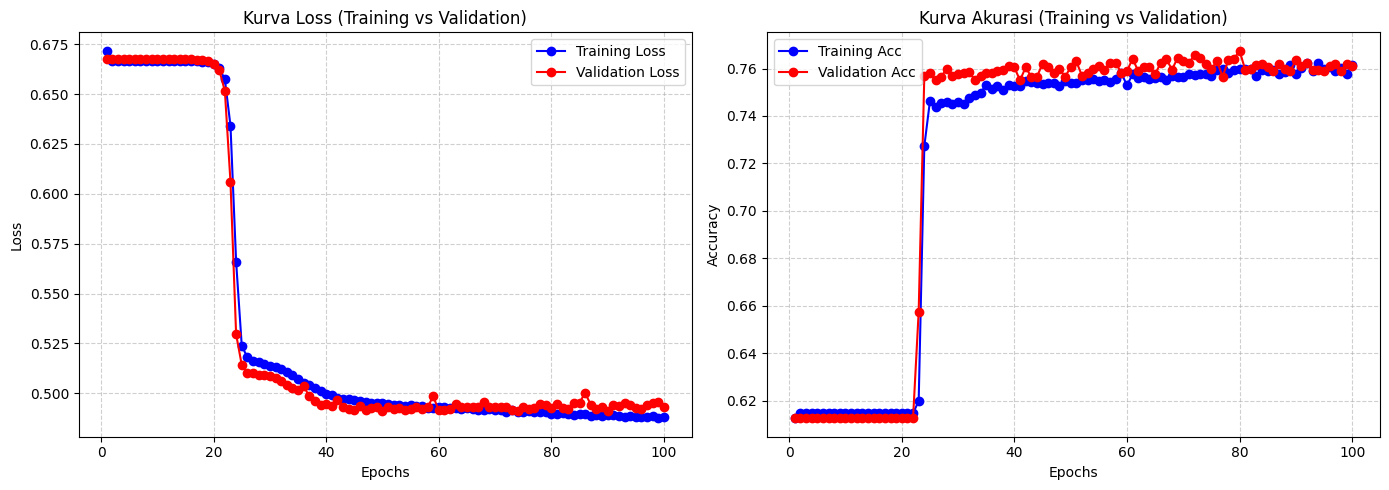


MODEL 2 - CLASSIFICATION REPORT
--- Laporan Klasifikasi ---
Total Data : 2000
Akurasi    : 76.10%

CONFUSION MATRIX - MODEL 2
[[ 476  299]
 [ 179 1046]]

MODEL 2 - DIAGNOSTIC
Initial train loss: 0.671764
Final train loss: 0.487955
Initial train accuracy: 0.612500
Final train accuracy: 0.761528
Test accuracy: 0.761000


In [33]:
print("="*60)
print("ATTEMPT 2: Higher Learning Rate with Better Initialization")
print("="*60)

# Re-import fresh
from ffnn.ffnn import FFNN
from ffnn import utils
from ffnn import losses

model2 = FFNN(
    layer_sizes=[input_dim, 32, 16, num_classes],
    activations=["relu", "relu", "softmax"],
    init_method="random_normal",
    learning_rate=0.1,  # Much higher learning rate
    epochs=100,
    batch_size=32,
    l2_lambda=0.0, 
    verbose=1,
    variance=0.1, 
    seed=42
)

print("\nTraining Model 2 with LR=0.1...")
history2 = model2.fit(
    X_train, y_train_onehot,
    X_val=X_test, y_val=y_test_onehot
)

utils.plot_history(history2)

# Predictions
y_pred_probs2 = model2.predict(X_test)
y_pred_labels2 = np.argmax(y_pred_probs2, axis=1)

print("\n" + "="*60)
print("MODEL 2 - CLASSIFICATION REPORT")
print("="*60)
utils.classification_report(y_test.ravel(), y_pred_labels2)

print("\n" + "="*60)
print("CONFUSION MATRIX - MODEL 2")
print("="*60)
print(confusion_matrix(y_test.ravel(), y_pred_labels2))

# Diagnostic
print("\n" + "="*60)
print("MODEL 2 - DIAGNOSTIC")
print("="*60)
print(f"Initial train loss: {history2['train_loss'][0]:.6f}")
print(f"Final train loss: {history2['train_loss'][-1]:.6f}")
print(f"Initial train accuracy: {history2['train_acc'][0]:.6f}")
print(f"Final train accuracy: {history2['train_acc'][-1]:.6f}")
print(f"Test accuracy: {np.mean(y_pred_labels2 == y_test.ravel()):.6f}")

### 1. Hyperparameter

### 2. Pengaruh Regularisasi

### 3. Uji Perbandingan dengan Library sklearn MLP

In [34]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Buat model sklearn MLP
sklearn_model = MLPClassifier(
    hidden_layer_sizes=(32, 16),
    activation='relu',
    solver='adam',
    learning_rate_init=0.01,
    max_iter=100,
    batch_size=32,
    random_state=42,
    verbose=1
)

# Training
print("Training sklearn MLPClassifier...")
sklearn_model.fit(X_train, y_train.ravel())

# Prediksi
y_pred_sklearn = sklearn_model.predict(X_test)

# Comparison Report
print("\n" + "="*60)
print("PERBANDINGAN MODEL")
print("="*60)

# Custom FFNN accuracy
y_pred_custom_labels = np.argmax(y_pred_probs, axis=1)
accuracy_custom = np.mean(y_pred_custom_labels == y_test.ravel())
print(f"\nCustom FFNN Accuracy: {accuracy_custom:.4f}")

# sklearn accuracy
accuracy_sklearn = accuracy_score(y_test.ravel(), y_pred_sklearn)
print(f"sklearn MLPClassifier Accuracy: {accuracy_sklearn:.4f}")

print("\n" + "="*60)
print("SKLEARN MODEL - CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_test.ravel(), y_pred_sklearn))

print("\n" + "="*60)
print("CONFUSION MATRIX - SKLEARN")
print("="*60)
print(confusion_matrix(y_test.ravel(), y_pred_sklearn))

Training sklearn MLPClassifier...
Iteration 1, loss = 0.52733291
Iteration 2, loss = 0.50815729
Iteration 3, loss = 0.50185189
Iteration 4, loss = 0.49719774
Iteration 5, loss = 0.49573295
Iteration 6, loss = 0.49534482
Iteration 7, loss = 0.49410379
Iteration 8, loss = 0.49167162
Iteration 9, loss = 0.49019083
Iteration 10, loss = 0.48828760
Iteration 11, loss = 0.48627589
Iteration 12, loss = 0.48535497
Iteration 13, loss = 0.48475245
Iteration 14, loss = 0.48304471
Iteration 15, loss = 0.48034722
Iteration 16, loss = 0.47740176
Iteration 17, loss = 0.47805309
Iteration 18, loss = 0.47714138
Iteration 19, loss = 0.47598328
Iteration 20, loss = 0.47339357
Iteration 21, loss = 0.47239506
Iteration 22, loss = 0.47161022
Iteration 23, loss = 0.47180982
Iteration 24, loss = 0.46606290
Iteration 25, loss = 0.46755497
Iteration 26, loss = 0.46489257
Iteration 27, loss = 0.46547312
Iteration 28, loss = 0.46383830
Iteration 29, loss = 0.46281886
Iteration 30, loss = 0.46057445
Iteration 31, l

c:\Users\saman\miniconda3\envs\segmentasimedis\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:780: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
